In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.stats.power as smp
from scipy import stats
from tqdm.notebook import tqdm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

**Кейс**
Давайте попробуем применить SPRT анализ в реальном АБ-тесте. Вы работаете аналитиков в команде искателей. Команда внедрила новую карточку объявлений авто. Основная цель вырастить конверсию в контакт в рамках одной сессии.
Аб-тест закончился и нам нужно проанализировать  результаты. У нас есть следующие данные:
cont_conv_A - конверсия по i-му пользователю в А группе
cont_conv_B - конверсия по j-му пользователю в B группе
данные в обоих колонках отсортированы по мере поступления в тест, т.е. более ранние строки это пользователи попавшие в тест раньше.
Менеджерам нужно дать ответ помогло ли изменение карточки авто повысить конверсию.

**Задания**
- 1. Проведем базовый z-тест на пропорцию. Тест двусторонний
- 2. Проведем SPRT анализ
- 3. Найти среднее время остановки SPRT анализа и сравнить с Fixed Horizon
- 4. Оценить мощность SPRT методики на наших данных

# SPRT для разницы долей / средних

In [ ]:
# создадим функцию проводящую тест на проверку гипотезы о равенстве долей с попощью SPRT
def get_decision_list_sprt_binom(values_A, values_B, alpha = 0.05, beta = 0.2, mde = 0.1):
    ''' Функция проводящая SPRT анализ для пропорций (долей, конверсий)
    values_A - массив значенений коверсии (0, 1) в группе А
    values_B - массив значенений коверсии (0, 1) в группе B
    alpha - уровень статзначимости, который выдерживает SPRT
    beta - уровень ошибки второго рода, который выдерживает SPRT
    mde - абсолютная разница между долями в двух группах, MDE проверяемый в SPRT

    return
    - early_stop_index: индекс на котором SPRT остановился и принял решение.
        Если по результатам всех наблюдений SPRT не смог принять решение возвращается len(data)
    - inference: какая гипотеза была принята по результатам SPRT
    - h0_bound_list: массив границ для принятия решения H0. Длиной early_stop_index
    - h1_bound_list: массив границ для принятия решения H1. Длиной early_stop_index
    - S_list: массив рассчитываемых значений отражающих изменение динамики разницы долей. Длиной early_stop_index
    - cum_diff_list: массив кумулятивной нарастающей разницы между долями в двух группах. Длиной early_stop_index
    '''
    min_len = int(np.mean([len(values_A), len(values_B)]))
    A = math.log(beta/(1 - alpha))
    B = math.log((1 - beta)/alpha)
    p = (values_A.mean() + values_B.mean())/2 # генеральная доля по двум выборкам

    h0_bound_list = []
    h1_bound_list = []
    S_list = []
    cum_diff_list = []

    for i in range(100, min_len):
        p0_i = np.mean(values_A[0:i])
        p1_i = np.mean(values_B[0:i])

        #p = (p0_i + p1_i)/2

        disp = p * (1 - p)
        diff = p1_i - p0_i
        h0_bound = 2 * disp * A / mde
        h1_bound = 2 * disp *  B / mde

        S = (i + 1) * (diff - mde/2)

        h0_bound_list.append(h0_bound)
        h1_bound_list.append(h1_bound)
        S_list.append(S)
        cum_diff_list.append(diff)

        if S < h0_bound:
            return {'early_stop_index':i, 'inference':'Accept H0', 'h0_bound_list': h0_bound_list, 'h1_bound_list': h1_bound_list, 'S_list': S_list, 'cum_diff_list':cum_diff_list}
        if S > h1_bound:
            return {'early_stop_index':i, 'inference':'Accept H1', 'h0_bound_list': h0_bound_list, 'h1_bound_list': h1_bound_list, 'S_list': S_list, 'cum_diff_list':cum_diff_list}
    return {'early_stop_index':i, 'inference':'Continue', 'h0_bound_list': h0_bound_list, 'h1_bound_list': h1_bound_list, 'S_list': S_list, 'cum_diff_list':cum_diff_list}

# Загружаем данные

In [ ]:
#Загружаем данные
data = pd.read_csv('SPRT_homework_1.csv')
data

,cont_conv_A,cont_conv_B
0,0,0
1,0,0
2,1,0
3,1,0
4,0,0
...,...,...
21253,0,0
21254,0,0
21255,0,0
21256,0,0


### Задание 1. Проведем базовый z-тест на пропорцию
Задание 3. Укажите p-value z-test

In [ ]:
#проведем базовый z-test на пропорцию

nobs = [len(data['cont_conv_A']), len(data['cont_conv_B'])]
counts = [np.sum(data['cont_conv_A'] == 1), np.sum(data['cont_conv_B'] == 1)]

stat, pval = proportions_ztest(count=counts, nobs=nobs) # считаем точечную оценку доли для z-теста
print('Задание 3. p-value z-test:', round(pval, 3))

Задание 3. p-value z-test: 0.024


# Задание 2. Проведем SPRT анализ
2. Укажите какая гипотеза верна по мнению SPRT?

Вывод: Accept H1
На каком наблюдении сделан вывод: 15314


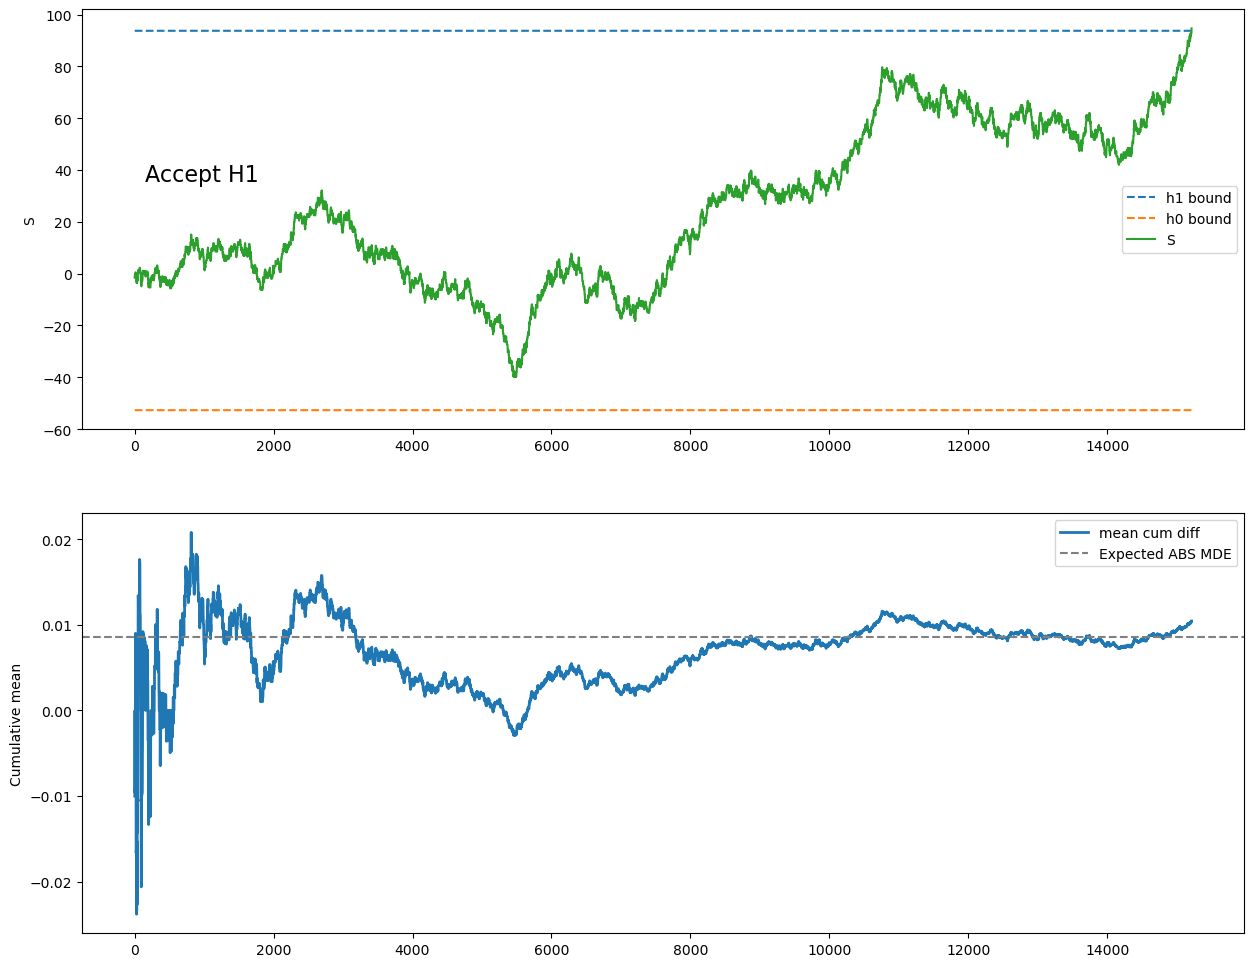

In [ ]:
# определим абсолютный MDE для проверки в SPRT
h0 = data['cont_conv_A'].mean()
rel_mde = 0.05
h1 = h0 * (1 + rel_mde)
mde_abs = h0*rel_mde

# проводим SPRT тест на полученных данных
values_A = data['cont_conv_A']
values_B = data['cont_conv_B']
inference_object = get_decision_list_sprt_binom(values_A, values_B, alpha = 0.05, beta = 0.2, mde = mde_abs)
print('Вывод:', inference_object['inference'])
print('На каком наблюдении сделан вывод:', inference_object['early_stop_index'])

fig, axes = plt.subplots(2, figsize=(15,12))

sns.lineplot(ax=axes[0], x = np.arange(1, len(inference_object['h0_bound_list'])+1), y = inference_object['h1_bound_list'], ls = '--', label='h1 bound')
sns.lineplot(ax=axes[0], x = np.arange(1, len(inference_object['h1_bound_list'])+1), y = inference_object['h0_bound_list'], ls = '--', label='h0 bound')
sns.lineplot(ax=axes[0], x = np.arange(1, len(inference_object['S_list'])+1), y = inference_object['S_list'], label='S')
axes[0].set_ylabel(ylabel = "S")
axes[0].text(y = np.quantile(inference_object['S_list'], 0.65), x = len(inference_object['S_list']) * 0.01, s = inference_object['inference'], fontsize = 16)
axes[0].legend()

sns.lineplot(ax=axes[1], x = np.arange(1, len(inference_object['h0_bound_list'])+1), y = inference_object['cum_diff_list'], label='mean cum diff', linewidth=2)
axes[1].axhline(mde_abs, ls='--', color='gray', label = 'Expected ABS MDE')
axes[1].set_ylabel(ylabel = "Cumulative mean")
axes[1].legend()

In [ ]:
print('2. Верна по мнению SPRT ->', inference_object['inference'])

2. Верна по мнению SPRT -> Accept H1


## Задание 3. Определим в среднем на каком размере выборки мы бы останавливались имея на руках наши текущие данные (оценка размера выборки для SPRT)
3.1 Определим размер выборки нужный для fixed horizon
- **параметры дизайна**
- относительный MDE = 0.05
- альфа = 0.05
- бета = 0.2
- гипотеза - двусторонняя
- пропорция в выборке 50/50
- исторические данные - данные по конверсии в группе А

3.2 Определить среднее время остоновки для АА симуляций
- **Параметры симуляции**
- перед запуском указать np.random.seed(2)
- кол-во симуляций = 300
- для симуляции будем брать исторические данные многократно выборки кодом np.random.choice(data['cont_conv_A'], size = len(data['cont_conv_A'])). replace по умолчанию = True
- размер выборок в симуляции = sample size с предыдущего шага

3.3 Определить среднее время остоновки для АБ симуляций
- **Параметры симуляции те же**

3.4 Оцените мощность методики SPRT на имеющихся данных группы А и Б и относительном MDE = 0.05
- **Параметры симуляции те же**


In [ ]:
# определим размер выборки нужный для Fixed Horizon для proportion тест
# за основу возбмите данные по группе А из данных теста.


h0 = data['cont_conv_A'].mean()
real_lift = data['cont_conv_B'].mean() - data['cont_conv_A'].mean()
rel_mde = 0.05
h1 = h0 * (1 + rel_mde)
alpha = 0.05
beta = 0.2
mde_abs = h0*rel_mde

cohen_d = 2*math.asin(np.sqrt(h0)) - 2*math.asin(np.sqrt(h0 * (1+rel_mde)))
n_obs = smp.zt_ind_solve_power(effect_size = cohen_d,
                           alpha = alpha,
                           power = 1 - beta,
                           alternative='two-sided')

sample_size = round(n_obs)

print('Размер выборки для Fixed Horizon:', sample_size)
print('mde_absolute:', round(mde_abs, 4))
print('real_lift:', real_lift)

Размер выборки для Fixed Horizon: 31121
mde_absolute: 0.0085
real_lift: 0.00832627716624329


## Симуляция по оценке среднего времени остановки SPRT теста и оценки мощности теста

In [ ]:
inference_AA_list = []
inference_AB_list = []
stop_index_list_AA = []
stop_index_list_AB = []
diffs_list_AA = []
diffs_list_AB = []
sim_num = 300
np.random.seed(2)
for i in tqdm(range(sim_num)):
    # сгенерируем данные с конверсией с h0 и h1 конверсиями (с размером выборок с запасом)
    values_A1 = np.random.choice(data['cont_conv_A'], size = sample_size )
    values_A2 = np.random.choice(data['cont_conv_A'], size = sample_size )  # выборка для АА симуляции
    values_B = np.random.choice(data['cont_conv_B'], size = sample_size) # выборка с добавленным эффектом

    inference_object_AA = get_decision_list_sprt_binom(values_A1, values_A2, alpha = 0.05, beta = 0.2, mde = mde_abs)
    inference_object_AB = get_decision_list_sprt_binom(values_A1, values_B, alpha = 0.05, beta = 0.2, mde = mde_abs)

    inference_AA = inference_object_AA['inference']
    inference_AB = inference_object_AB['inference']
    stop_index_AA = inference_object_AA['early_stop_index']
    stop_index_AB = inference_object_AB['early_stop_index']

    inference_AA_list.append(inference_AA)
    inference_AB_list.append(inference_AB)
    stop_index_list_AA.append(stop_index_AA)
    stop_index_list_AB.append(stop_index_AB)

FP = (np.array(inference_AA_list) =='Accept H1').sum() / sim_num
FP_CI = proportion_confint((np.array(inference_AA_list)=='Accept H1').sum() , sim_num, alpha=0.05)
power = (np.array(inference_AB_list) =='Accept H1').sum() / sim_num
power_CI = proportion_confint((np.array(inference_AB_list)=='Accept H1').sum() , sim_num, alpha=0.05)

print('FP rate =', FP)
print('Power rate =', power)
print('Stop index AA:', round(np.mean(stop_index_list_AA)))
print('Stop index AB:', round(np.mean(stop_index_list_AB)))

# распределение времени остановки теста на конверсии с относительным MDE 5%
plt.figure(figsize = (12, 8))
sns.kdeplot(stop_index_list_AA, label = 'stop index AA', color = 'grey')
sns.kdeplot(stop_index_list_AB, label = 'stop index AB', color = 'green')
plt.axvline(x = np.mean(stop_index_list_AA), ls = '--', color = 'grey')
plt.xlabel('n')
plt.axvline(x = np.mean(stop_index_list_AB), ls = '--', color = 'green')
plt.axvline(x = sample_size, label = 'fixed horizon sample size', color = 'red')
plt.axvline(x = np.mean(stop_index_list_AA), ls = '--', color = 'grey')
plt.legend()

  0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
print('3.2. Среднее время остановки SPRT теста для АА-варианта =', round(np.mean(stop_index_list_AA)))
print('3.3. Среднее время остановки SPRT теста для АБ-варианта =', round(np.mean(stop_index_list_AB)))
print('3.4. Оценка мощности SPRT теста', power)

3.2. Среднее время остановки SPRT теста для АА-варианта = 10696
3.3. Среднее время остановки SPRT теста для АБ-варианта = 14547
3.4. Оценка мощности SPRT теста 0.7366666666666667
